In [1]:
from google.colab import files
uploaded = files.upload()

Saving dataset_amb.mat to dataset_amb.mat
Saving dataset_elec.mat to dataset_elec.mat


In [2]:
import scipy.io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#Files
FILE_ELEC = 'dataset_elec.mat'
FILE_AMB = 'dataset_amb.mat'

#File Handling
try:
    elec_data = scipy.io.loadmat(FILE_ELEC)
    amb_data = scipy.io.loadmat(FILE_AMB)
    print(f"Files '{FILE_ELEC}' and '{FILE_AMB}' loaded successfully.")

except FileNotFoundError:
    print("\n--- ERROR ---")
    print(f"File not found. Please ensure you have uploaded '{FILE_ELEC}' and '{FILE_AMB}'")
    print("to the Colab environment using 'from google.colab import files; files.upload()' first.")
    raise

# --- Extract and store the data to a single dataFrame----
data = {}

# Electrical data keys: 'vdc1', 'vdc2', 'idc1', 'idc2'
for key in ['vdc1', 'vdc2', 'idc1', 'idc2']:
    data[key] = elec_data[key].flatten()

# Ambient and Fault data keys: 'irr', 'pvt', 'f_nv'
for key in ['irr', 'pvt', 'f_nv']:
    data[key] = amb_data[key].flatten()

# DataFrame creation
df = pd.DataFrame(data)
df = df.rename(columns={'f_nv': 'Fault_Label'})

Files 'dataset_elec.mat' and 'dataset_amb.mat' loaded successfully.


In [11]:
len(df)

1373798

In [8]:
import pandas as pd
import numpy as np
from scipy.io import loadmat



# 3. Create the timestamp column
# If you don't have a timestamp, we'll generate one starting from '2024-01-01' at 1s intervals
df['timestamp'] = pd.date_range(start='2024-01-01', periods=len(df), freq='1S')

# 4. Split into a list of 16 DataFrames
days = [group for _, group in df.groupby(df['timestamp'].dt.date)]

# 5. Accessing a specific day (e.g., Day 1)
day1 = days[0]
print(f"Day 1 has {len(day1)} readings.")

/tmp/ipython-input-952069752.py:10: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df['timestamp'] = pd.date_range(start='2024-01-01', periods=len(df), freq='1S')


Day 1 has 86400 readings.


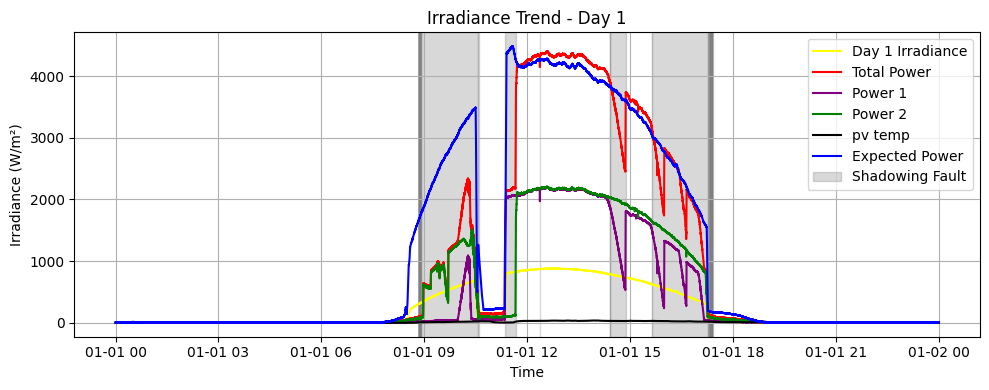

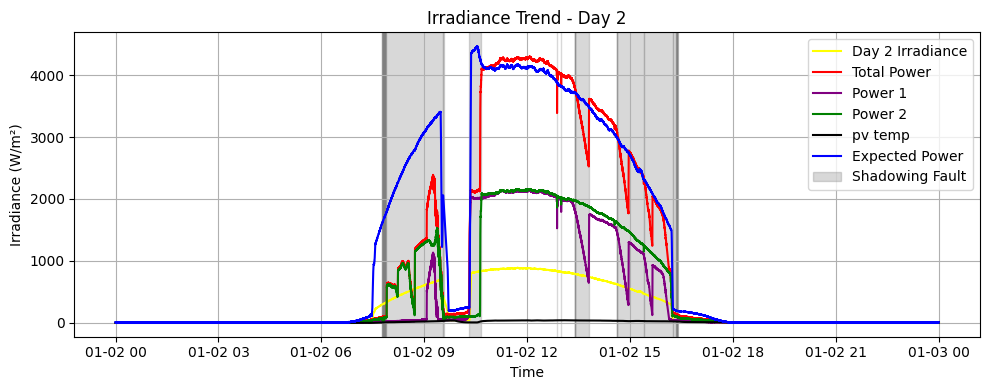

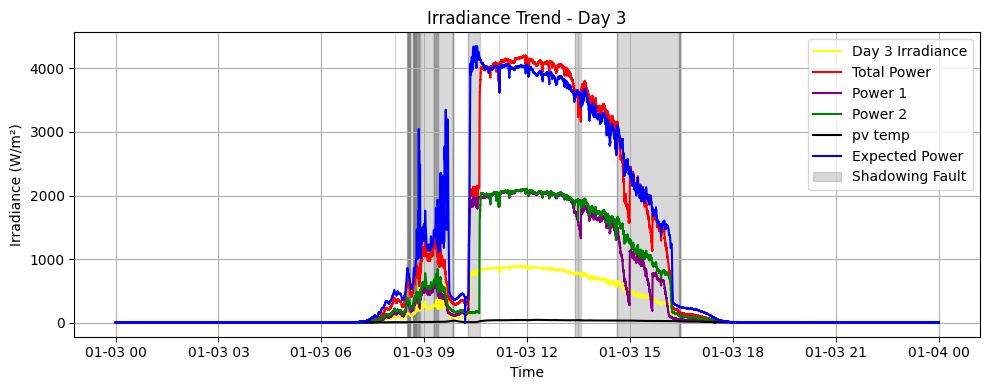

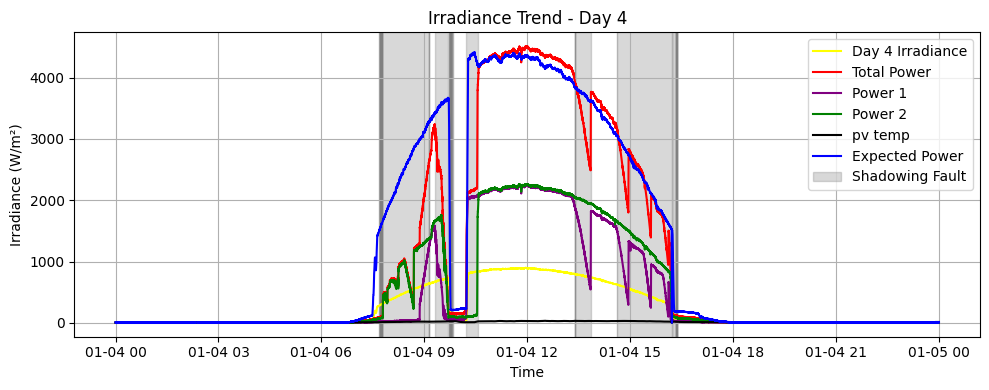

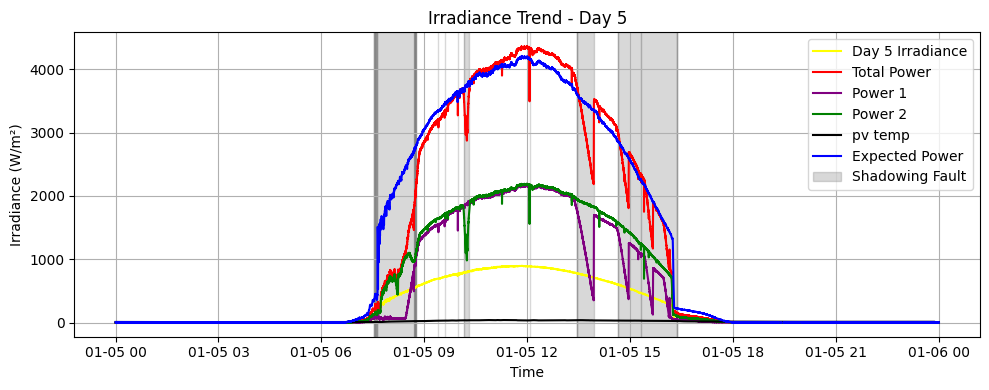

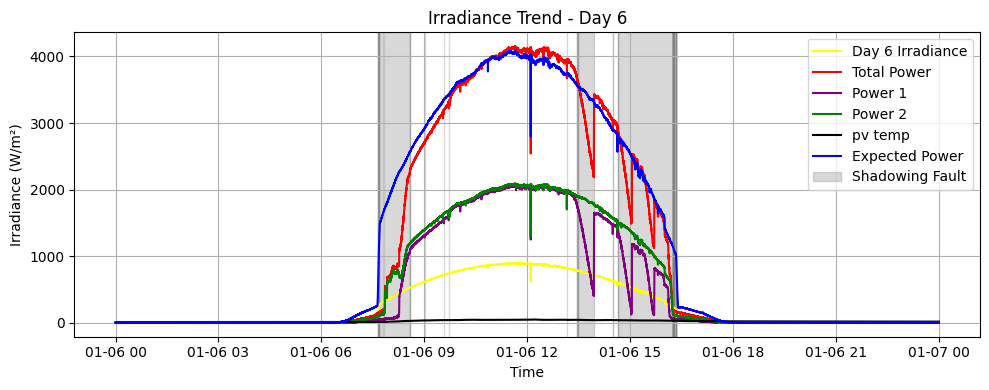

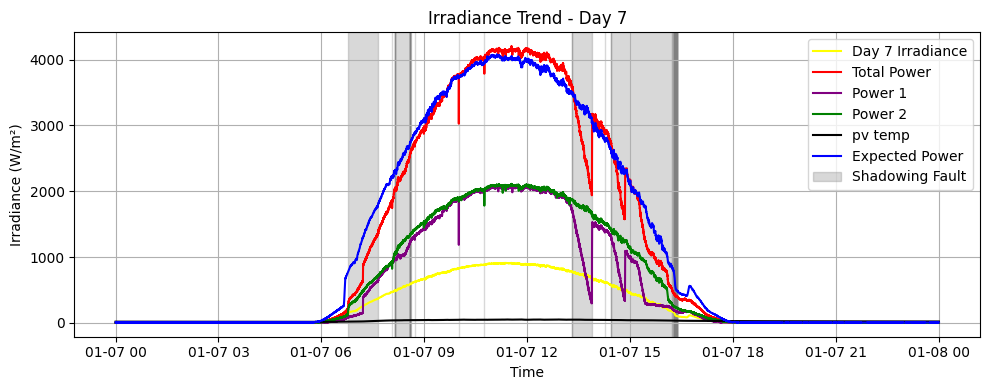

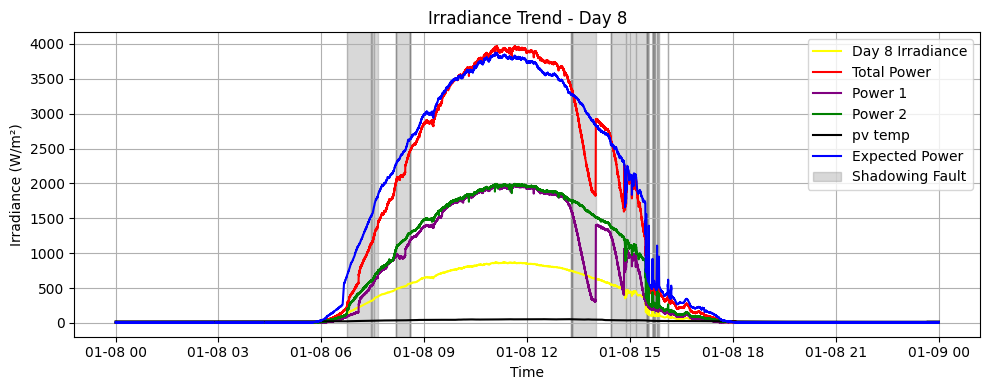

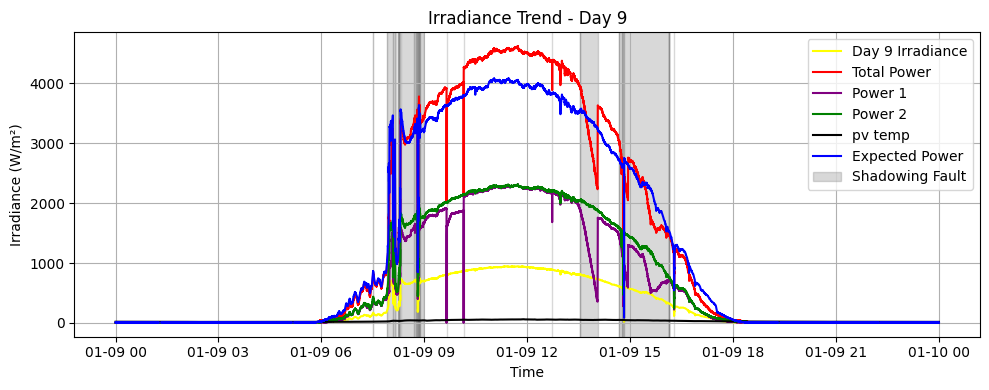

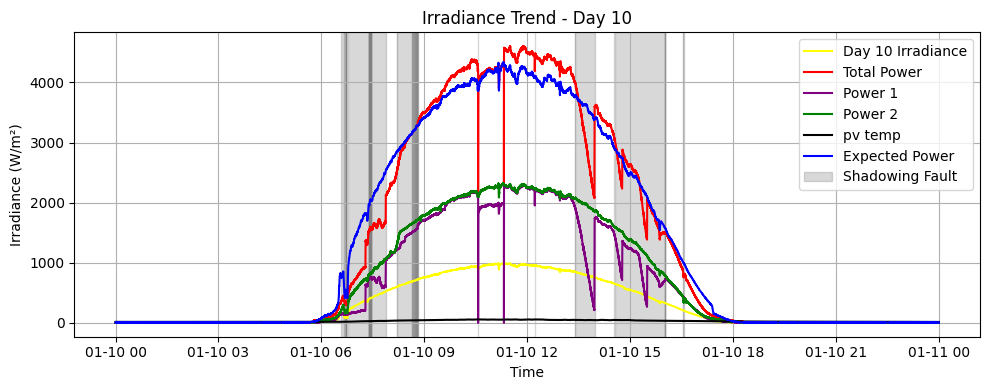

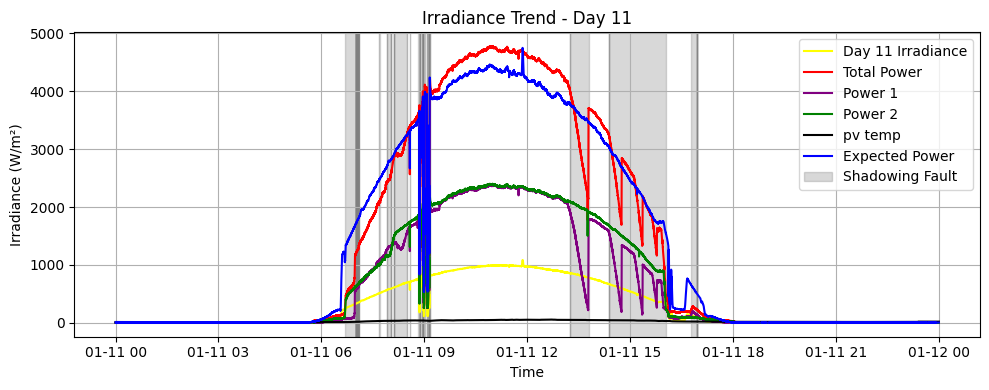

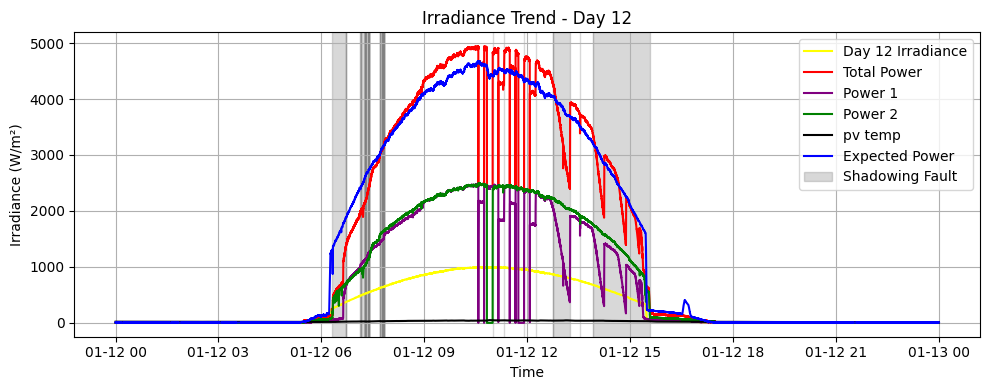

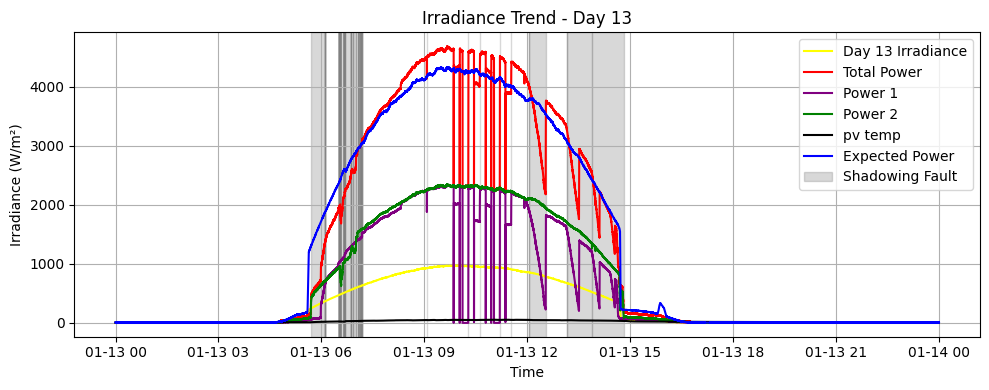

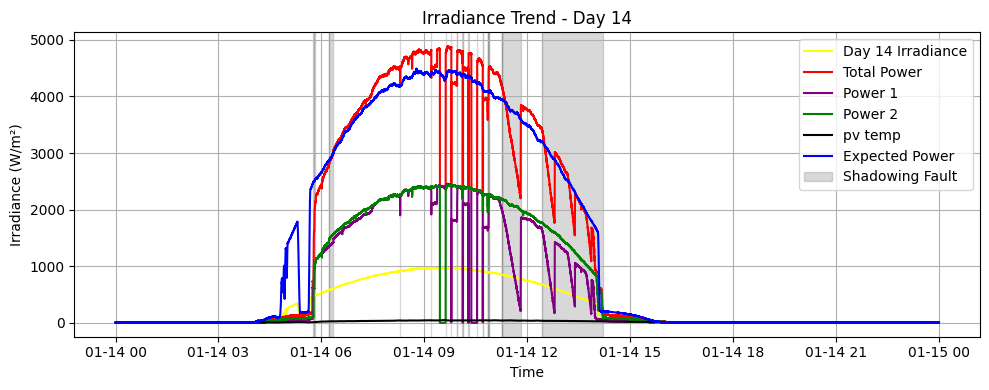

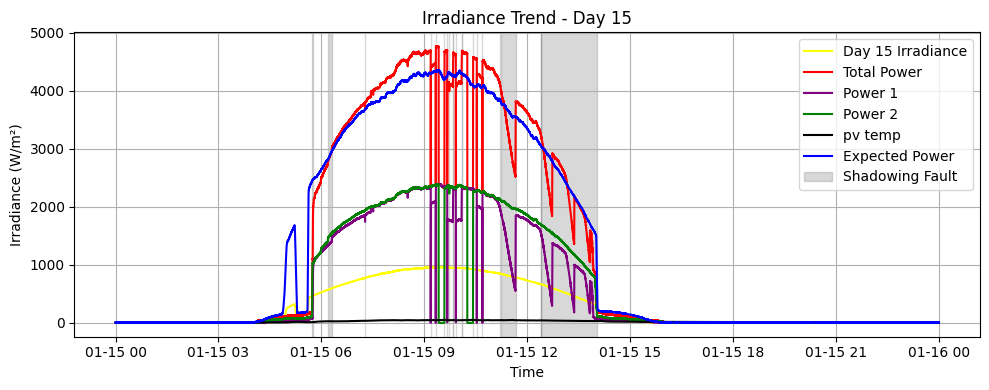

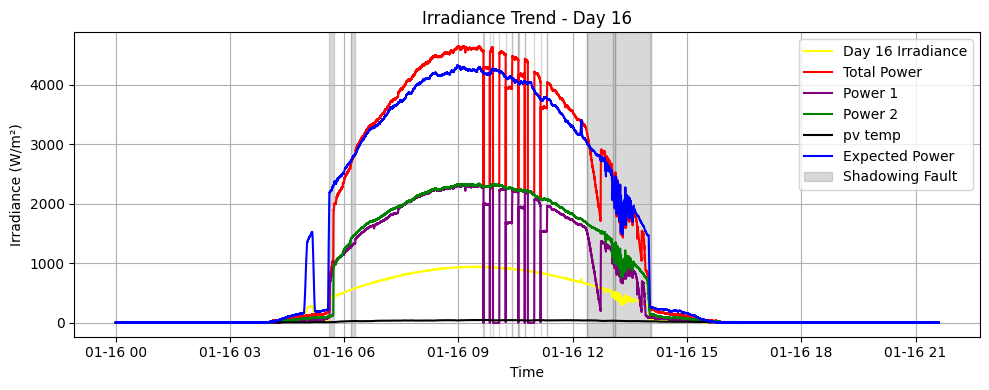

In [24]:
def caluclateActualPower(day):
     # Calculate Actual Power (Watts)
    day['p_total']=day['p_actual1'] = (day['vdc1'] * day['idc1']) + (day['vdc2'] * day['idc2'])
    day['p_actual1'] = day['vdc2'] * day['idc2']
    day['p_actual2'] = day['vdc1'] * day['idc1']


def calculateExpectedPower(day):
    day['p_expected'] = (day['irr'] / 1000) * P_NOMINAL * (1 - TEMP_COEFF * (day['pvt'] - 25))

def highlight_shadowing(day, ax):
    """
    Finds contiguous blocks where Fault_Label is 4 and highlights them.
    """
    # Find indices where fault is active
    shadow_indices = day.index[day['Fault_Label'] == 4].tolist()

    if not shadow_indices:
        return

    # To draw a "strip", we need a start and end time.
    # This logic groups consecutive fault readings into single blocks.
    start_time = None

    for i in range(len(day)):
        # If fault starts
        if day.iloc[i]['Fault_Label'] == 4 and start_time is None:
            start_time = day.iloc[i]['timestamp']

        # If fault ends or it's the last reading
        elif (day.iloc[i]['Fault_Label'] != 4 or i == len(day) - 1) and start_time is not None:
            end_time = day.iloc[i]['timestamp']
            # Draw the vertical highlight strip
            ax.axvspan(start_time, end_time, color='gray', alpha=0.3, label='Shadowing Fault' if 'Shadowing Fault' not in ax.get_legend_handles_labels()[1] else "")
            start_time = None



for i, day in enumerate(days):
 caluclateActualPower(day)
 calculateExpectedPower(day)
 plt.figure(figsize=(10, 4)) # Create a new figure for each day
 ax = plt.gca() # Get the current Axes object
 plt.plot(day.timestamp, day.irr, color='yellow',label=f'Day {i+1} Irradiance')
 plt.plot(day.timestamp,day.p_total,color='red',label='Total Power')
 plt.plot(day.timestamp,day.p_actual1,color='purple',label='Power 1')
 plt.plot(day.timestamp,day.p_actual2,color='green',label='Power 2')
 plt.plot(day.timestamp,day.pvt,color='black',label='pv temp')

 plt.plot(day.timestamp,day.p_expected,color='blue',label='Expected Power')

 highlight_shadowing(day, ax)
 plt.title(f'Irradiance Trend - Day {i+1}')
 plt.xlabel('Time')
 plt.ylabel('Irradiance (W/m²)')
 plt.grid(True)
 plt.legend()
 plt.tight_layout()
 plt.show()